In [1]:
import os

train_path = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images"
train_csv  = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv"

In [2]:
val_path = "/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images"
val_csv  = "/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv"

In [3]:
import pandas as pd

val_df = pd.read_csv(val_csv)

print(val_df.head())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [4]:
import pandas as pd

train_df = pd.read_csv(train_csv)
print(train_df.head())

        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0


In [5]:
print("Total Images:", len(os.listdir(train_path)))
print("CSV Entries:", len(train_df))

Total Images: 2930
CSV Entries: 2930


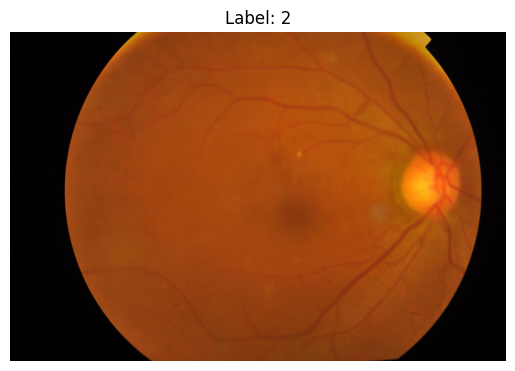

In [6]:
import cv2
import matplotlib.pyplot as plt

img_name = train_df.iloc[0]['id_code']
img_path = os.path.join(train_path, img_name + ".png")

img = cv2.imread(img_path)

if img is None:
    print("Error:", img_path)
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Label: {train_df.iloc[0]['diagnosis']}")
    plt.axis("off")

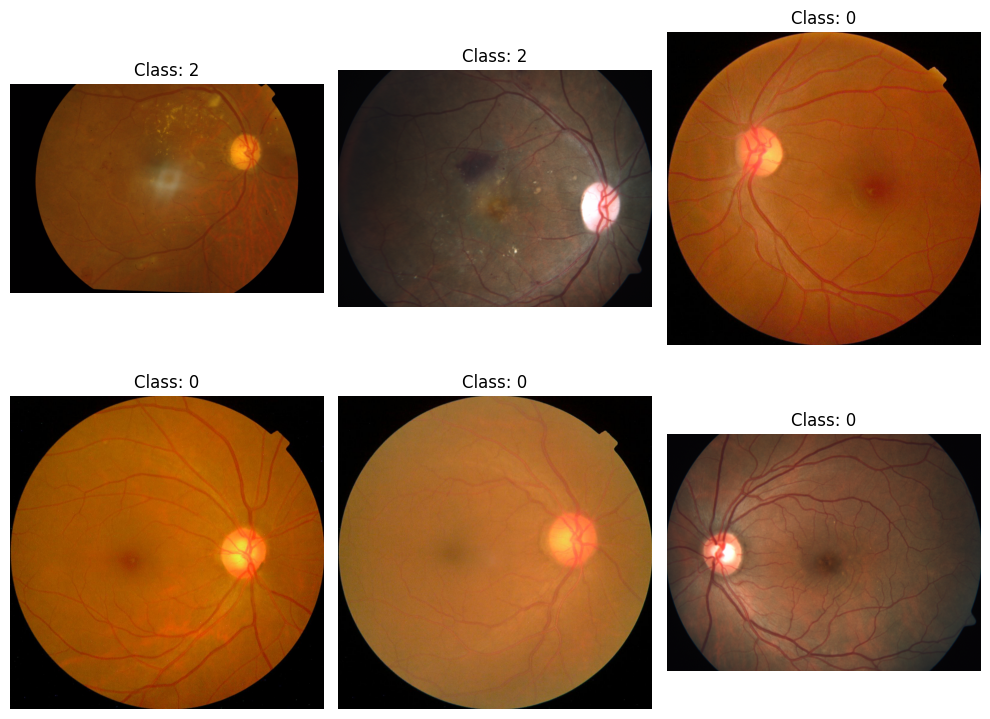

In [7]:
import random

plt.figure(figsize=(10,8))

for i in range(6):
    idx = random.randint(0, len(train_df)-1)
    img_name = train_df.iloc[idx]['id_code']
    label = train_df.iloc[idx]['diagnosis']
    
    img_path = os.path.join(train_path, img_name + ".png")
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.tight_layout()

Text(0.5, 1.0, 'Class Distribution')

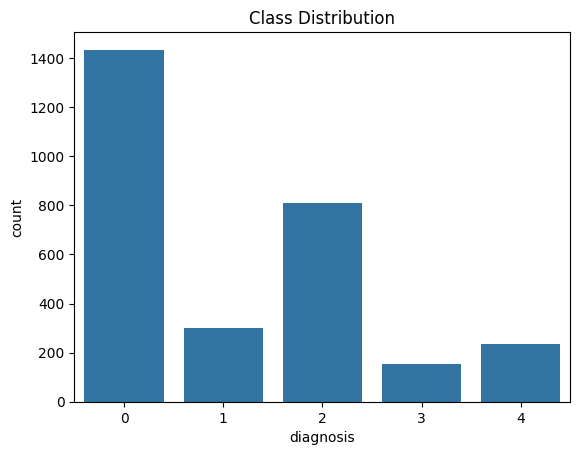

In [8]:
import seaborn as sns

sns.countplot(x=train_df['diagnosis'])
plt.title("Class Distribution")

In [9]:
print(train_df['diagnosis'].value_counts())

diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64


In [10]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A

In [11]:
def crop_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)

    return img[y:y+h, x:x+w]

In [12]:
def ben_graham(img, sigma=10):
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blur, -4, 128)

In [13]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

In [14]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

In [15]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.Rotate(limit=10, p=0.5, border_mode=cv2.BORDER_REFLECT),

    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.1),

    A.Resize(224, 224),
])

In [16]:
def preprocess_and_augment(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    # 🔹 Preprocessing
    img = crop_image(img)
    img = ben_graham(img)
    img = apply_clahe(img)

    # 🔹 Augmentation
    augmented = train_transform(image=img)
    img = augmented['image']

    # 🔹 Normalize
    img = img / 255.0

    return img

In [17]:
def preprocess_only(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    img = crop_image(img)
    img = ben_graham(img)
    img = apply_clahe(img)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0

    return img

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

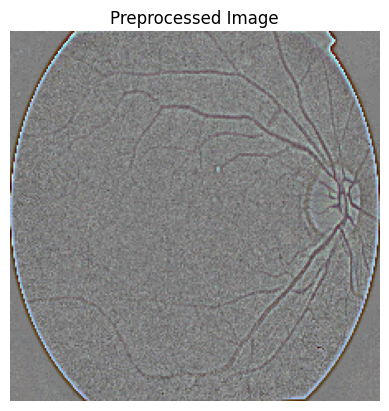

In [18]:
img_name = train_df.iloc[0]['id_code']
img_path = os.path.join(train_path, img_name + ".png")

img = preprocess_only(img_path)

plt.imshow(img)
plt.title("Preprocessed Image")
plt.axis("off")

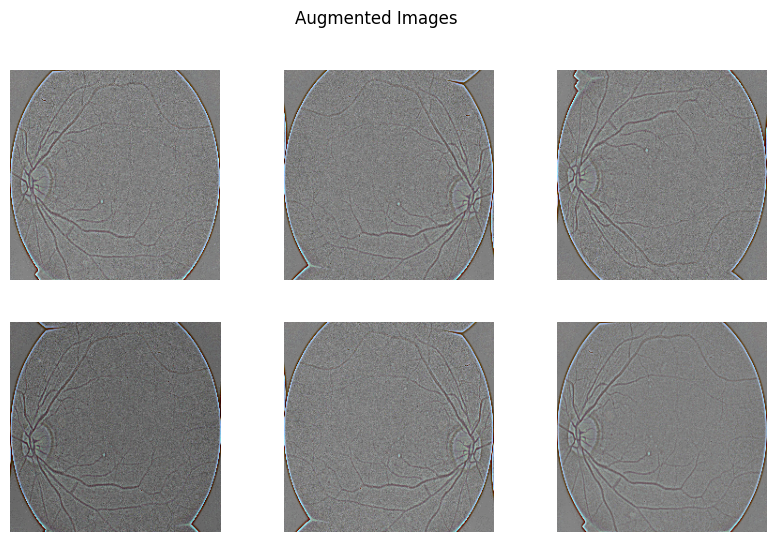

In [19]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = preprocess_and_augment(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Augmented Images")
plt.show()

In [20]:
!pip install timm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score

In [22]:
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform_fn):
        self.df = df
        self.img_dir = img_dir
        self.transform_fn = transform_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id_code']
        label = self.df.iloc[idx]['diagnosis']

        img_path = os.path.join(self.img_dir, img_name + ".png")

        img = self.transform_fn(img_path)

        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)

        return img, torch.tensor(label, dtype=torch.long)

In [23]:
train_dataset = DRDataset(train_df, train_path, preprocess_and_augment)
val_dataset   = DRDataset(val_df, val_path, preprocess_only)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [25]:
class DRModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0
        )

        # 🔥 Automatically get feature size
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 5)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DRModel().to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [27]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(5),
    y=train_df['diagnosis'].values
)

weights = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [28]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [29]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [30]:
def evaluate(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(predictions)
            targets.extend(labels.numpy())

    kappa = cohen_kappa_score(targets, preds, weights='quadratic')

    return kappa

In [31]:
best_kappa = -1   # 🔥 fix

epochs = 30

for epoch in range(epochs):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_kappa = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation QWK: {val_kappa:.4f}")

    # ✅ Save BEST model
    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("✅ Best Model Saved!")

    # 🔥 ALWAYS SAVE (important)
    torch.save(model.state_dict(), "/kaggle/working/last_model.pth")

    scheduler.step()


Epoch 1
Train Loss: 1.2124
Validation QWK: 0.8124
✅ Best Model Saved!



Epoch 2
Train Loss: 0.9842
Validation QWK: 0.8552
✅ Best Model Saved!



Epoch 3
Train Loss: 0.8862
Validation QWK: 0.8473
